# Machine Learning: Regressions

**Objectives:**
- Load and explore a dataset
- Split data into training and test sets
- Train regression models with scikit-learn (Linear, Lasso, Ridge)
- Evaluate model performance using $R^2$ scores
- Understand the purpose of cross-validation (k-fold)

We work through two datasets:  
1. **Diabetes dataset** — a small, pre-normalized dataset to learn the ML workflow  
2. **California Housing dataset** — a larger, real-world dataset to practice sparse regressions

---
## Part 1: Diabetes Dataset — Basic Regression

### Step 1: Import and Explore the Data

We start by loading the **diabetes dataset** from scikit-learn.  
It contains 10 baseline variables (age, sex, BMI, blood pressure, etc.) for 442 patients,  
and a target variable measuring disease progression one year later.

The dataset is returned as a dictionary with keys: `'data'`, `'target'`, `'feature_names'`, `'DESCR'`.

In [60]:
import sklearn
import sklearn.datasets

dataset = sklearn.datasets.load_diabetes()

# The result is a dictionary:
# 'data'          -> features (X)
# 'target'        -> labels (y)
# 'feature_names' -> names of the features
# 'DESCR'         -> description of the dataset

In [61]:
print(dataset['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

Let's put the data into a **pandas DataFrame** for easier exploration.

In [62]:
import pandas

df = pandas.DataFrame(dataset['data'], columns=dataset['feature_names'])
df['disease_progression'] = dataset['target']

In [63]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,disease_progression
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


> **Interpretation:** Notice that the means of the features are close to zero and the standard deviations are similar across variables. This tells us the data has already been **normalized** (centered and scaled). Normalization is important so that no single feature dominates the regression just because of its scale.

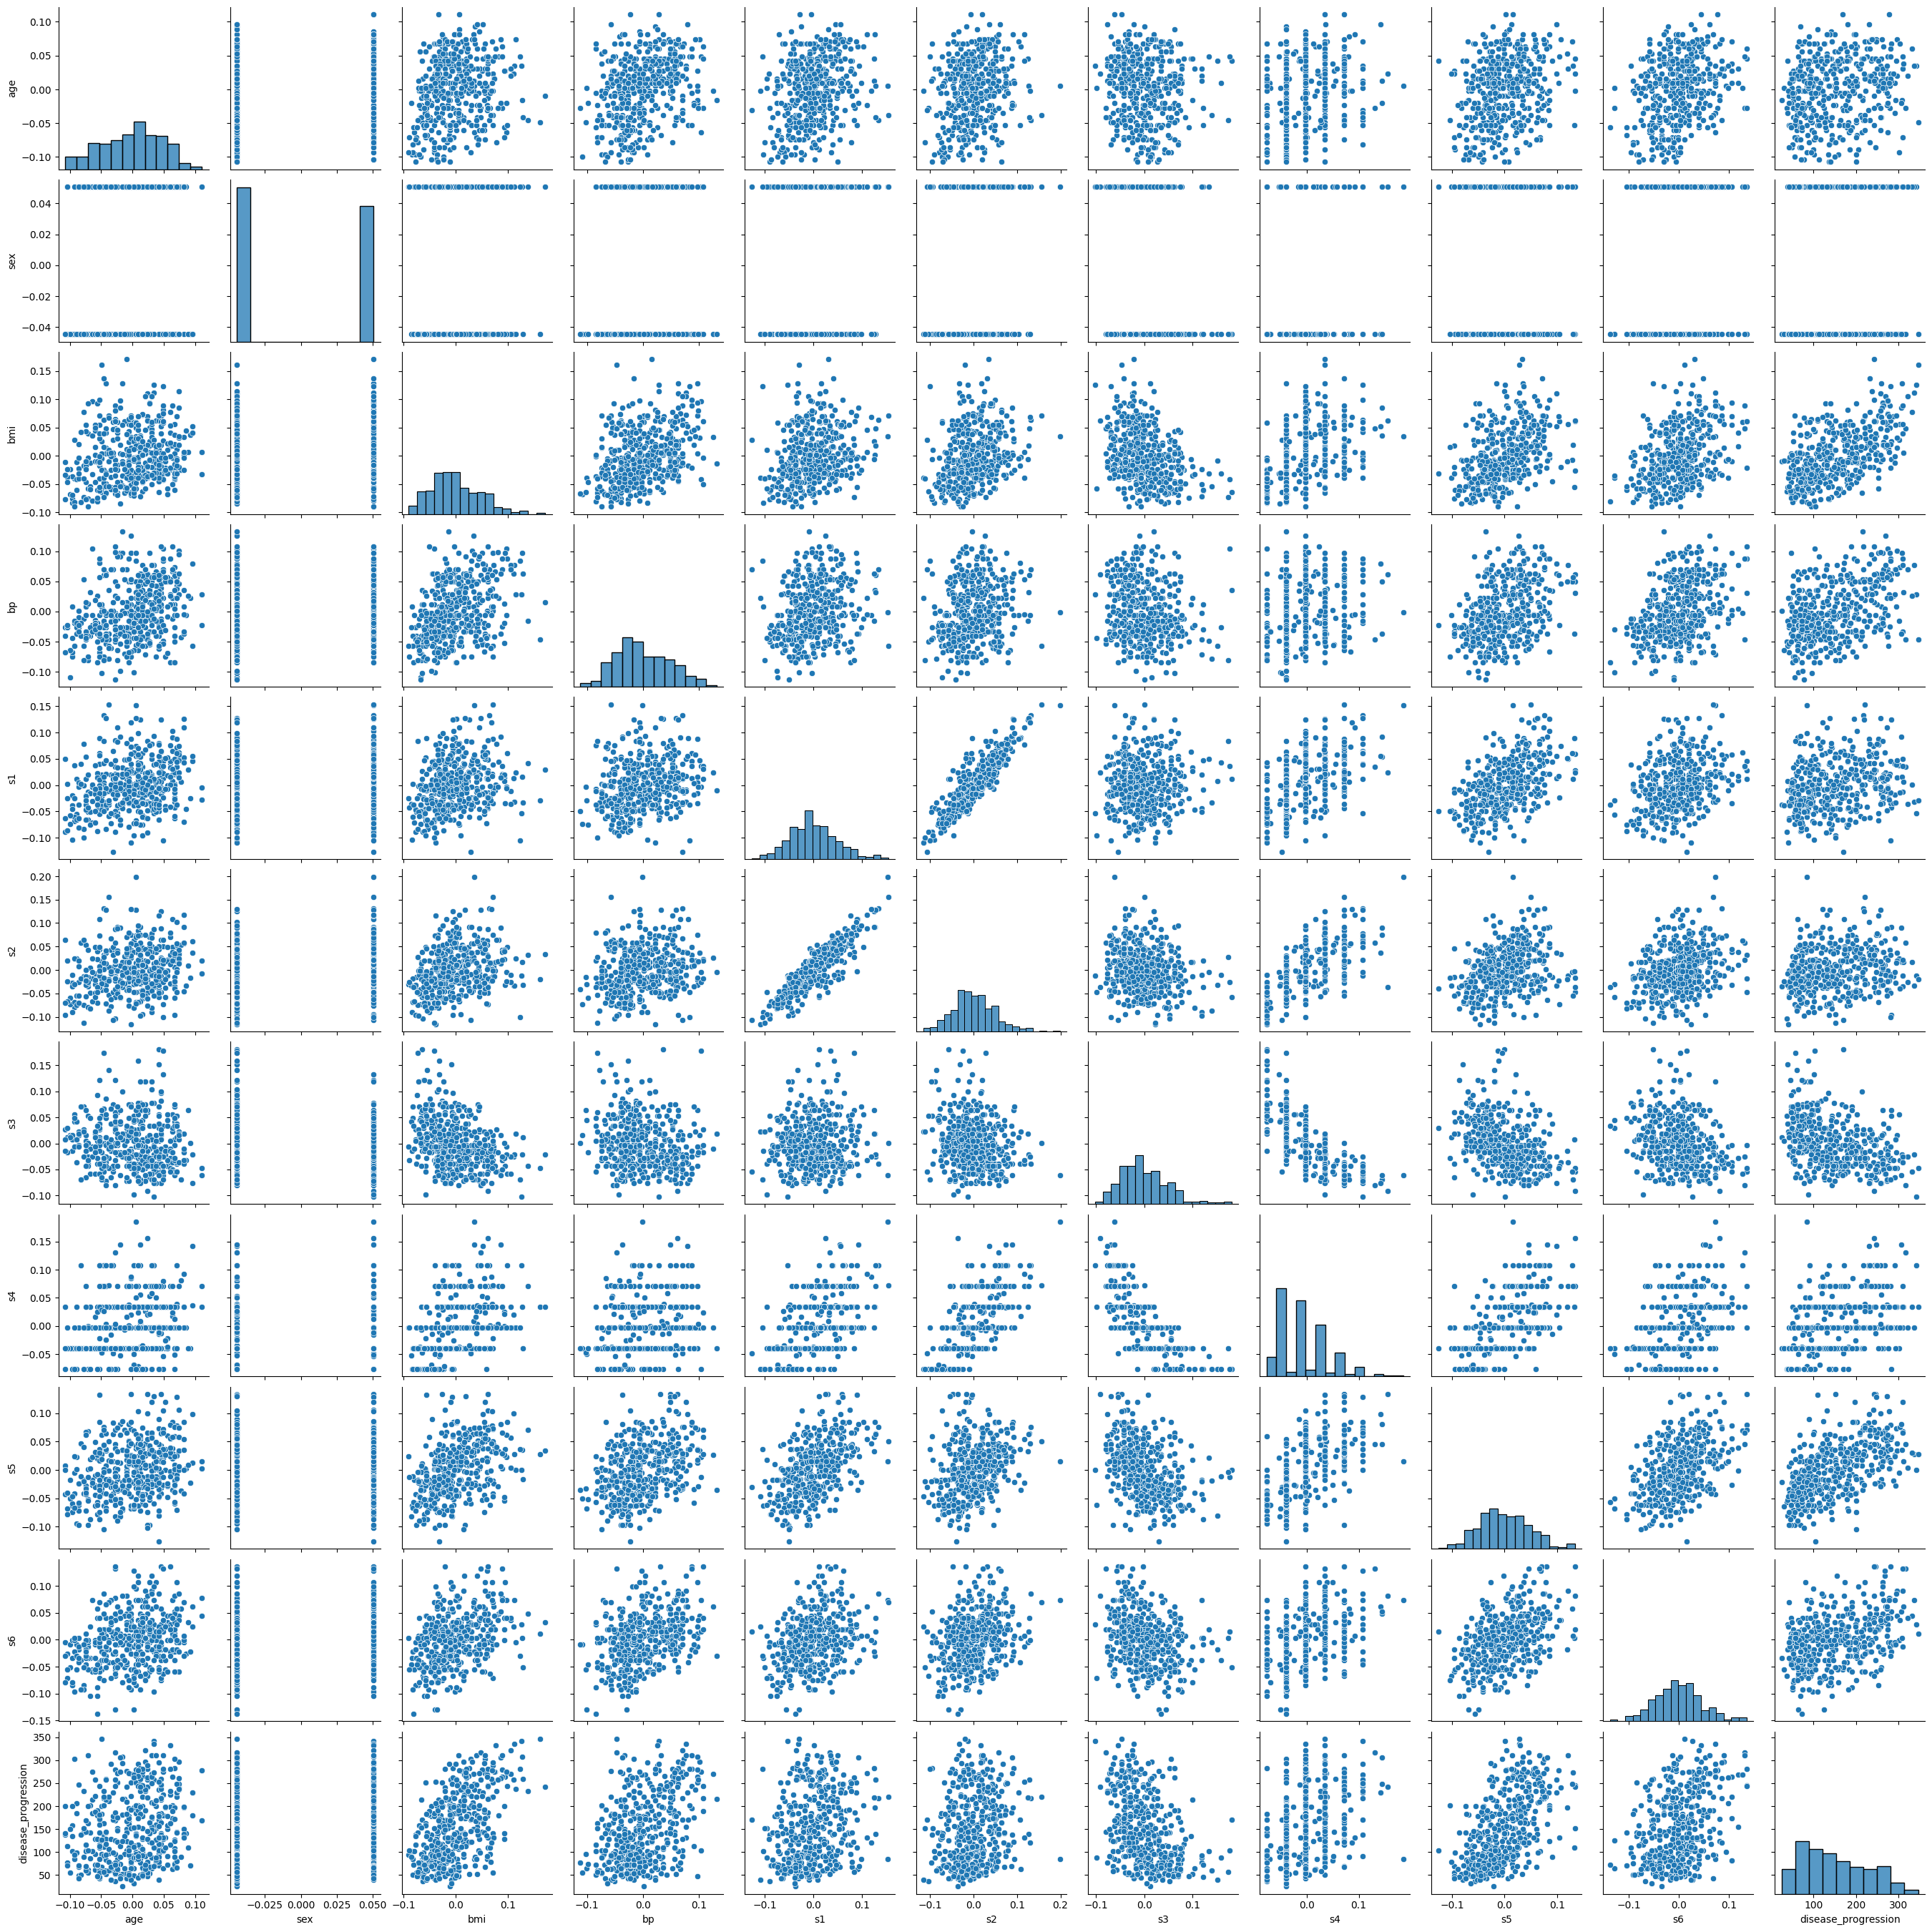

In [64]:
import seaborn
seaborn.pairplot(df)

---
### Step 2: Split Into Training and Test Sets

**Why do we split?** We want to evaluate our model on data it has *never seen* during training.  
This tells us how well the model **generalizes** to new observations (out-of-sample performance).

We use 70% for training and 30% for testing.

In [65]:
from sklearn.model_selection import train_test_split

In [66]:
# Features: one row per observation, one column per feature
print("Features shape:", dataset['data'].shape)

# Target: what we are trying to predict (disease progression)
print("Target shape:", dataset['target'].shape)

Features shape: (442, 10)
Target shape: (442,)


In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    dataset['data'], dataset['target'],
    test_size=0.3,
    random_state=56  # fixed seed for reproducibility
)

---
### Step 3: Train a Linear Regression Model

**What is linear regression?**  
We fit a model: $\hat{y} = a + b_1 x_1 + b_2 x_2 + \ldots + b_{10} x_{10}$  
where $a$ is the intercept and $b_i$ are the coefficients.

Scikit-learn makes this very simple: create a model object, then call `.fit()`.

In [68]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()  # create model object
model.fit(X_train, y_train)  # train it on the training data

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [69]:
# Intercept (a)
print("Intercept:", model.intercept_)

Intercept: 152.82810842206453


In [70]:
# Coefficients (b_1, b_2, ..., b_10)
print("Coefficients:", model.coef_)

Coefficients: [   3.04174075 -209.76813682  501.77871853  286.88207011 -991.92731799
  603.10838272  228.80501285  226.30296964  905.67772303   92.55739263]


---
### Step 4: Evaluate the Model

We use the **$R^2$ score** to evaluate model quality.  
$R^2 = 1$ means perfect prediction; $R^2 = 0$ means the model predicts no better than the mean.

We check *both* the training score and the test score to look for **overfitting**.  
If the training score is much higher than the test score, the model memorized the training data rather than learning general patterns.

In [15]:
print("Test R² score: ", model.score(X_test, y_test))
print("Train R² score:", model.score(X_train, y_train))

Test R² score:  0.6031839133200351
Train R² score: 0.6072326244780315


> **Interpretation:** The test and training scores are relatively close, so overfitting is not a major concern here. However, the $R^2$ is moderate (~0.5), meaning the linear model captures only about half of the variance in disease progression.

---
### Step 5: Should We Adjust the Test Set Size?

One might wonder: *Does the size of the test set matter?*  Let's try different splits and see how the score changes.


In [16]:
sizes = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
scores = []

for s in sizes:
    X_train, X_test, y_train, y_test = train_test_split(
        dataset['data'], dataset['target'], test_size=s
    )
    model = LinearRegression()
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    scores.append(score)

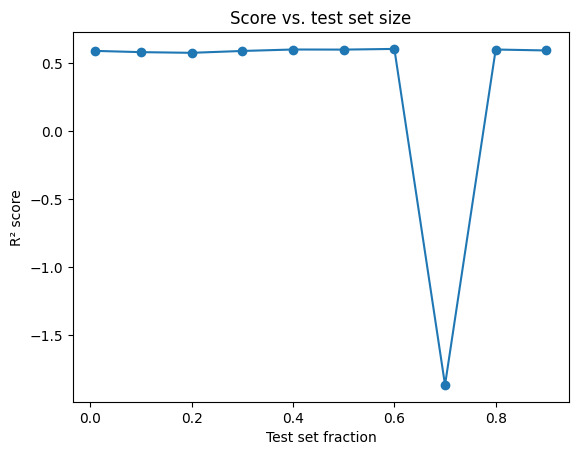

In [17]:
from matplotlib import pyplot as plt
plt.plot(sizes, scores, marker='o')
plt.xlabel('Test set fraction')
plt.ylabel('R² score')
plt.title('Score vs. test set size')
plt.show()

> **Interpretation:** The score fluctuates depending on the split. This illustrates a key problem: a *single* train/test split gives an unstable estimate of model performance. The solution? **Cross-validation.**

### Step 6: K-Fold Cross-Validation

**Why cross-validation?**  
A single train/test split can give an unstable estimate of model performance because results depend on how the data was randomly divided.  
K-fold cross-validation improves this by repeating the evaluation several times using different parts of the data.

**How it works**

1. The dataset is divided into $k$ equal parts (called folds).  
2. The model is trained $k$ times.  
3. Each time, a different fold is used as the test set, while the remaining $k-1$ folds are used for training.  
4. The $k$ test scores are averaged to obtain a more reliable estimate of performance.

**Train and test proportions**

In K-fold cross-validation, the proportions are fixed by $k$:

Test share: $\frac{1}{k}$  
Train share: $\frac{k-1}{k}$

Examples:

- with $k=3$: Train ≈ 67%, Test ≈ 33%  
- with $k=5$: Train ≈ 80%, Test ≈ 20%

The proportions stay the same in each iteration, but the observations in the test set change.

<div style="display: flex; gap: 40px; align-items: flex-start;">

<div>

**Example (3-fold cross-validation)**

| Fold iteration | Training data | Test data |
|---|---|---|
| Fold 1 | Fold 2 + Fold 3 | Fold 1 |
| Fold 2 | Fold 1 + Fold 3 | Fold 2 |
| Fold 3 | Fold 1 + Fold 2 | Fold 3 |

This means:

- every observation is used for testing exactly once  
- every observation is used for training $k-1$ times  

</div>

<div>

**Observation-level view (3-fold cross-validation)**

| observation | fold block | Fold 1 | Fold 2 | Fold 3 |
|---|---|---|---|---|
| 0 | 0–147 | TEST | TRAIN | TRAIN |
| 1 | 0–147 | TEST | TRAIN | TRAIN |
| ... | ... | ... | ... | ... |
| 148 | 148–295 | TRAIN | TEST | TRAIN |
| ... | ... | ... | ... | ... |
| 441 | 296–441 | TRAIN | TRAIN | TEST |

</div>

</div>

**Computing performance (R² example)**

Suppose the test $R^2$ from each fold is: $R^2_1 = 0.47$, $R^2_2 = 0.49$, $R^2_3 = 0.51$

The cross-validation estimate is: $R^2_{CV} = \frac{0.47 + 0.49 + 0.51}{3} = 0.49$

We report the average test $R^2$ as our estimate of model performance.

In [18]:
from sklearn.model_selection import KFold

X = dataset['data']
y = dataset['target']
scores = []

kf = KFold(n_splits=3)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model = LinearRegression()
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    scores.append(score)

print(f"K-Fold scores: {scores}")
print(f"Mean score:   {sum(scores) / len(scores):.2f}")

K-Fold scores: [0.555021261943019, 0.5883783783109381, 0.5854464074342973]
Mean score:   0.58


> **Interpretation:** The k-fold scores give us a more reliable estimate of the model's predictive power. The average across folds is a better summary than any single split.

---
### Step 7: Introduction to Lasso Regression

**Lasso** (Least Absolute Shrinkage and Selection Operator) adds a penalty to the size of the coefficients:  it pushes some coefficients toward zero, effectively performing **variable selection**.

This can be useful when you suspect that not all features are relevant.

Note that for models to be comparable, they must be evaluated on the **same folds**.

In [19]:
from sklearn.linear_model import Lasso

scores = []

for train_index, test_index in kf.split(X):

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model_lasso = Lasso()
    model_lasso.fit(X_train, y_train)

    score = model_lasso.score(X_test, y_test)
    scores.append(score)

print("K-Fold scores:", scores)
print("Mean score:", sum(scores) / len(scores))

K-Fold scores: [0.2622793450039619, 0.29408192668416766, 0.232541428858]
Mean score: 0.26296756684870987


> **Interpretation:** The Lasso score on the test set is slightly worse than plain linear regression. This is because the **default regularization parameter** (`alpha=1.0`) may be too strong for this dataset, shrinking useful coefficients too much. Tuning `alpha` could improve performance.

**Optional (advanced): tuning the Lasso penalty**

So far we compared Linear Regression and Lasso using the **same outer K-fold splits**, which ensures a fair comparison.

However, Lasso has a hyperparameter **α (alpha)** controlling the strength of regularization. Using the default value may not be optimal.

To tune α **without leaking information from the test folds**, we use **nested cross-validation**:

• **Inner loop:** choose the best α on the training fold  
• **Outer loop:** evaluate the tuned model on the test fold

This keeps the evaluation fair and usually improves Lasso performance.

In [20]:

scores = []
best_alphas = []

alpha_grid = [0.001, 0.01, 0.1, 1, 10]

for train_index, test_index in kf.split(X):

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    alpha_scores = []

    for alpha in alpha_grid:

        inner_scores = []

        for inner_train_index, inner_test_index in kf.split(X_train):

            X_train_inner = X_train[inner_train_index]
            X_test_inner = X_train[inner_test_index]
            y_train_inner = y_train[inner_train_index]
            y_test_inner = y_train[inner_test_index]

            model_lasso = Lasso(alpha=alpha)
            model_lasso.fit(X_train_inner, y_train_inner)

            inner_scores.append(model_lasso.score(X_test_inner, y_test_inner))

        alpha_scores.append(sum(inner_scores) / len(inner_scores))

    best_alpha = alpha_grid[alpha_scores.index(max(alpha_scores))]
    best_alphas.append(best_alpha)

    model_lasso = Lasso(alpha=best_alpha)
    model_lasso.fit(X_train, y_train)

    score = model_lasso.score(X_test, y_test)
    scores.append(score)

print("Best alpha per fold:", best_alphas)
print("Outer K-Fold scores:", scores)
print("Mean score:", sum(scores) / len(scores))

Best alpha per fold: [0.001, 0.001, 0.01]
Outer K-Fold scores: [0.5551525972358098, 0.5886284859516436, 0.5720745719844269]
Mean score: 0.5719518850572934


Interpretation: The Lasso score on the test set is now equvialent linear regression.

**Comparing multiple models with tuning**

We now compare four models (with automatic tuning):
• Linear Regression  
• Lasso 
• Ridge 
• Elastic Net 

The **same outer K-fold splits** are used for all models to ensure a fair comparison.

For the regularized models, the best penalty parameter is selected **inside the training fold** using cross-validation, and the tuned model is then evaluated on the outer test fold.

In [22]:
from sklearn.linear_model import  RidgeCV, ElasticNetCV, LassoCV

scores_linear = []
scores_lasso = []
scores_ridge = []
scores_elastic = []

for train_index, test_index in kf.split(X):

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model_linear = LinearRegression()
    model_linear.fit(X_train, y_train)
    scores_linear.append(model_linear.score(X_test, y_test))

    model_lasso = LassoCV(cv=3)
    model_lasso.fit(X_train, y_train)
    scores_lasso.append(model_lasso.score(X_test, y_test))

    model_ridge = RidgeCV(alphas=[0.001, 0.01, 0.1, 1, 10])
    model_ridge.fit(X_train, y_train)
    scores_ridge.append(model_ridge.score(X_test, y_test))

    model_elastic = ElasticNetCV(cv=3)
    model_elastic.fit(X_train, y_train)
    scores_elastic.append(model_elastic.score(X_test, y_test))

print(f"Linear mean score: {sum(scores_linear) / len(scores_linear):.2f}")
print(f"Lasso mean score: {sum(scores_lasso) / len(scores_lasso):.2f}")
print(f"Ridge mean score: {sum(scores_ridge) / len(scores_ridge):.2f}")
print(f"Elastic Net mean score: {sum(scores_elastic) / len(scores_elastic):.2f}")

Linear mean score: 0.58
Lasso mean score: 0.56
Ridge mean score: 0.58
Elastic Net mean score: 0.56


---
## Part 2: California Housing — Sparse Regressions

Now we apply the same workflow to a larger, real-world dataset:  
the **California Housing** dataset (median house values across California districts).

__Import the California Housing Price Dataset from sklearn.__

In [23]:
from sklearn.datasets import fetch_california_housing
dataset = fetch_california_housing()

__Explore the data (description, correlations, histograms...)__

In [24]:
# print(dataset['DESCR'])
print(dataset.keys())
dataset['data']
dataset['target']
dataset['feature_names']

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])


['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [25]:
import pandas as pd
import seaborn as sns

# Convert sklearn dataset to pandas DataFrame
df = pd.DataFrame(dataset['data'], columns=dataset['feature_names'])
df['MedHouseValue'] = dataset['target']

In [26]:
# Quick inspection
#print(df.head())
print(df.describe())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude  MedHouseValue  
count  20640.000000  20640.000000  20640.000000   20640.000000  
mean       3.070655     35.631861   -119.569704       2.068558  
std       10.386050      2.135952      2.003532       1.153956  
min        0.692308     32.5

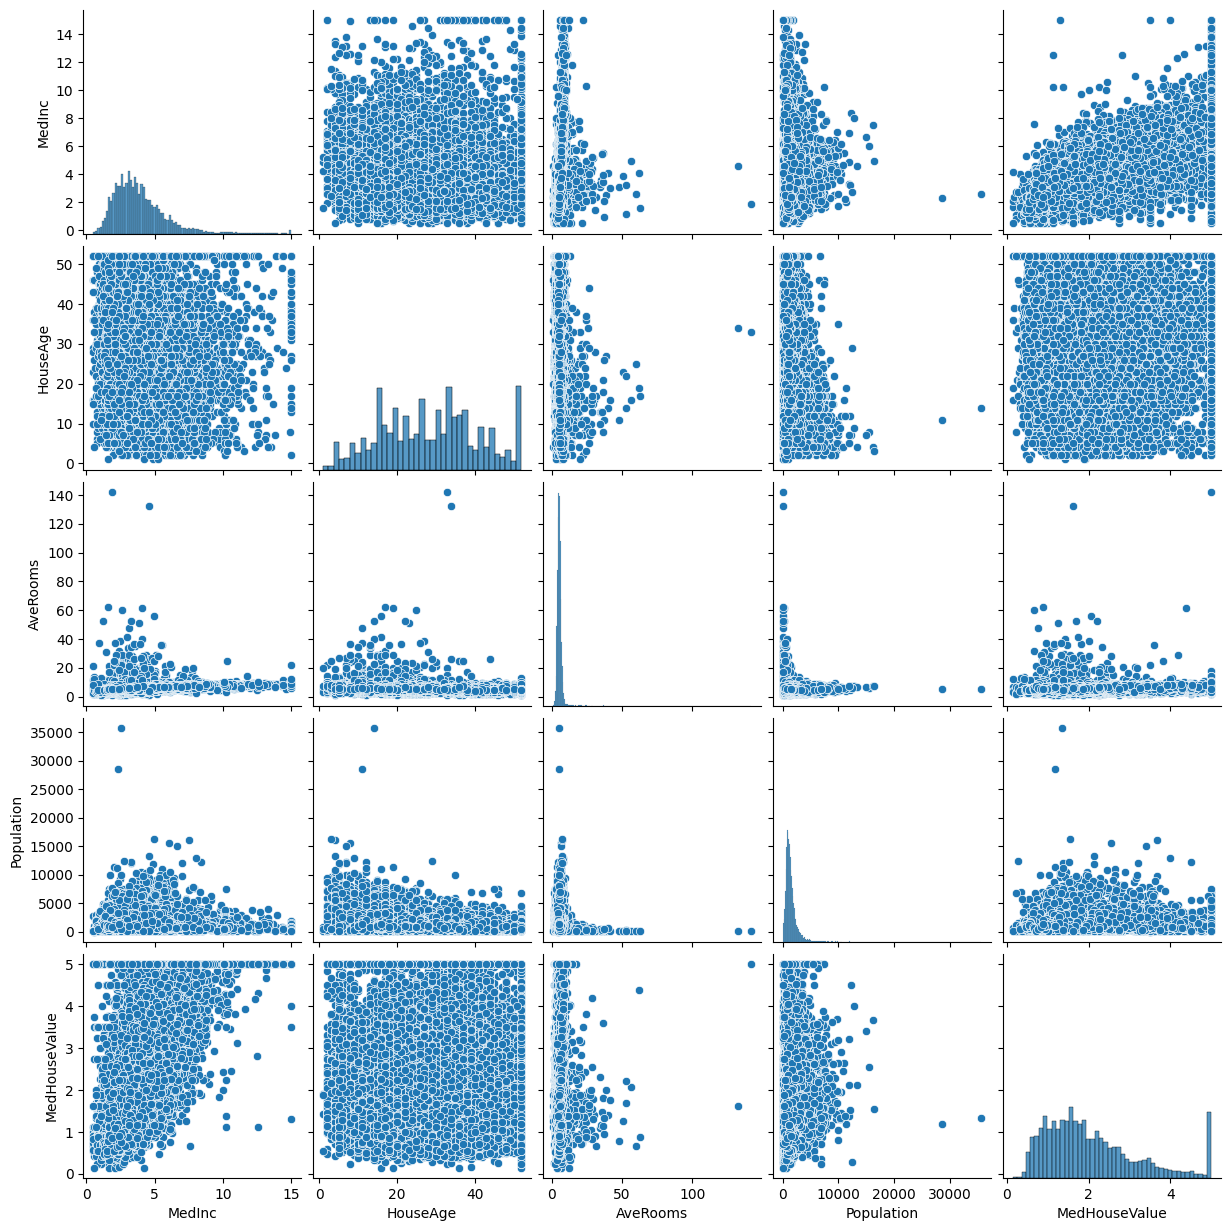

In [27]:
# Pairplot (subset for clarity in class)
sns.pairplot(df[['MedInc','HouseAge','AveRooms','Population','MedHouseValue']])

__Split the dataset into a training set (70%) and a test set (30%).__

In [ ]:
X = dataset['data']
y = dataset['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=58
)




In [30]:
# It seems like data is not normalized (scales of features are very different)
# For the lasso and ridge regression, we should standardize the features 
# to have mean=0 and std=1

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

__Train  a linear model on the training set (using sklearn).__ C

In [31]:
from sklearn.linear_model import LinearRegression

model_linear = LinearRegression()
model_linear.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


__Compute the fitting score on the test set. What is the problem? Should we adjust the size of the training set?__

In [32]:
print("Linear R² on test set:", model_linear.score(X_test, y_test))

Linear R² on test set: 0.6060131778750415


The problem is not the score itself — the issue is that it comes from only **one split**.

A single train/test split can be unstable because results depend on how the data
is randomly divided.

Instead of changing the training size, we use **cross-validation**, which averages
performance across multiple splits and gives a more reliable estimate.

In [33]:
# Use cross validation for linear regression
from sklearn.model_selection import KFold
scores_linear = []
kf = KFold(n_splits=3)
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model_linear = LinearRegression()
    model_linear.fit(X_train, y_train)
    scores_linear.append(model_linear.score(X_test, y_test))
    
print(f"Linear mean score: {sum(scores_linear) / len(scores_linear):.2f}")



Linear mean score: 0.58


__Train a lasso model to predict house prices. Compute the score on the test set.__

In [34]:
from sklearn.linear_model import Lasso

model_lasso = Lasso()
model_lasso.fit(X_train, y_train)
print("Lasso R² on test set:", model_lasso.score(X_test, y_test))

Lasso R² on test set: 0.232541428858


Lasso performs worse here because the default penalty is too strong
and the variables are not scaled. To compare fairly, we should tune hyperparameters and scale the data.

__Train a ridge model to predict house prices. Which one is better?__

In [35]:
from sklearn.linear_model import Ridge

model_ridge = Ridge()
model_ridge.fit(X_train, y_train)
print("Ridge R² on test set:", model_ridge.score(X_test, y_test))

Ridge R² on test set: 0.5854136107889254


Ridge usually performs better in this dataset because it shrinks coefficients more smoothly instead of forcing them to zero.


__(Bonus): For your preferred regression, implement the k-fold evaluation scheme to validate the model.__

In [36]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression, Lasso, Ridge

scores_linear = []
scores_lasso = []
scores_ridge = []

kf = KFold(n_splits=3)

for train_index, test_index in kf.split(X):

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # model_linear = LinearRegression()
    # model_linear.fit(X_train, y_train)
    # scores_linear.append(model_linear.score(X_test, y_test))

    # model_lasso = Lasso()
    # model_lasso.fit(X_train, y_train)
    # scores_lasso.append(model_lasso.score(X_test, y_test))

    model_ridge = Ridge()
    model_ridge.fit(X_train, y_train)
    scores_ridge.append(model_ridge.score(X_test, y_test))

# print("Linear K-fold scores:", scores_linear)
# print("Linear mean score:", sum(scores_linear) / len(scores_linear))

# print("Lasso K-fold scores:", scores_lasso)
#print("Lasso mean score:", sum(scores_lasso) / len(scores_lasso))

print("Ridge K-fold scores:", scores_ridge)
print("Ridge mean score:", sum(scores_ridge) / len(scores_ridge))

Ridge K-fold scores: [0.5550333443181903, 0.5883874505481572, 0.5854136107889254]
Ridge mean score: 0.5762781352184243


__(Bonus): Use k-fold cross-validation to compare Linear Regression, Lasso, Ridge, and Elastic Net. For the regularized models, tune the penalty parameter inside the training folds.__

In [37]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV, ElasticNetCV

scores_linear = []
scores_lasso = []
scores_ridge = []
scores_elastic = []

kf = KFold(n_splits=3)

for train_index, test_index in kf.split(X):

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model_linear = LinearRegression()
    model_linear.fit(X_train, y_train)
    scores_linear.append(model_linear.score(X_test, y_test))

    model_lasso = LassoCV(cv=3)
    model_lasso.fit(X_train, y_train)
    scores_lasso.append(model_lasso.score(X_test, y_test))

    model_ridge = RidgeCV(alphas=[0.001, 0.01, 0.1, 1, 10], cv=3)
    model_ridge.fit(X_train, y_train)
    scores_ridge.append(model_ridge.score(X_test, y_test))

    model_elastic = ElasticNetCV(cv=3)
    model_elastic.fit(X_train, y_train)
    scores_elastic.append(model_elastic.score(X_test, y_test))

print(f"Linear mean score: {sum(scores_linear) / len(scores_linear):.2f}")
print(f"Lasso mean score: {sum(scores_lasso) / len(scores_lasso):.2f}")
print(f"Ridge mean score: {sum(scores_ridge) / len(scores_ridge):.2f}")
print(f"Elastic Net mean score: {sum(scores_elastic) / len(scores_elastic):.2f}")

Linear mean score: 0.58
Lasso mean score: 0.56
Ridge mean score: 0.58
Elastic Net mean score: 0.56
